In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller


In [19]:
df = sns.load_dataset('flights')
df.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [22]:
airp= df[['passengers']].copy(deep=True)
print(airp)

# stationarity check
def test_stationary(df,var,window=12):
    df['rollmean']=df[var].rolling(window=window).mean()
    df['rollstd']=df[var].rolling(window=window).std()
    adf_result = adfuller(df[var])
    p_value = adf_result[1]
    print(f'ADF p-value:{p_value:.4f}')
    if p_value< 0.05:
        print('the time series is stationary (reject H0)')
    else:
        print('The time series is not stationary (fail to reject H0)')

    plt.figure(figsize=(10,5))
    sns.lineplot(x=df.index, y=df[var], label='Original')
    sns.lineplot(x=df.index, y=df['rollmean'], label='Rolling Mean')
    sns.lineplot(x=df.index, y=df['rollstd'], label='Rolling std')
    plt.title('Rolling statistics')
    plt.legend()
    plt.show()


    

     passengers
0           112
1           118
2           132
3           129
4           121
..          ...
139         606
140         508
141         461
142         390
143         432

[144 rows x 1 columns]


ADF p-value:0.9919
The time series is not stationary (fail to reject H0)


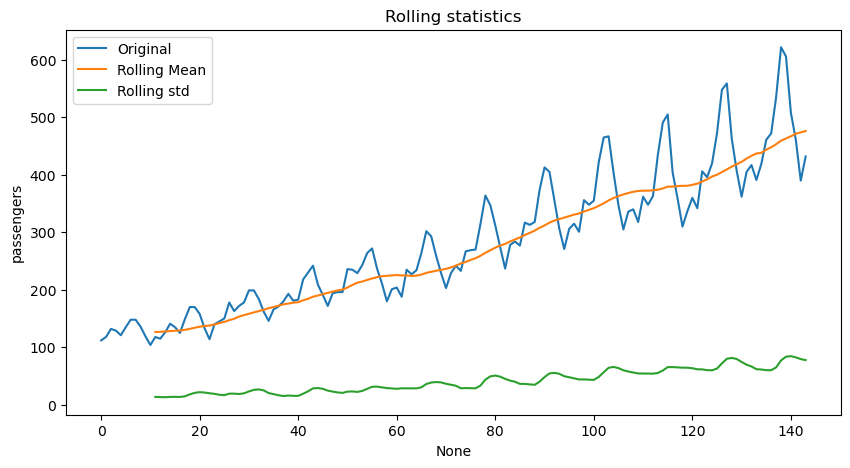

In [23]:
test_stationary(airp,'passengers')

    passengers    rollmean    rollstd  shift  shiftDiff
0          112         NaN        NaN    NaN        NaN
1          118         NaN        NaN  112.0        6.0
2          132         NaN        NaN  118.0       14.0
3          129         NaN        NaN  132.0       -3.0
4          121         NaN        NaN  129.0       -8.0
5          135         NaN        NaN  121.0       14.0
6          148         NaN        NaN  135.0       13.0
7          148         NaN        NaN  148.0        0.0
8          136         NaN        NaN  148.0      -12.0
9          119         NaN        NaN  136.0      -17.0
10         104         NaN        NaN  119.0      -15.0
11         118  126.666667  13.720147  104.0       14.0
12         115  126.916667  13.453342  118.0       -3.0
13         126  127.583333  13.166475  115.0       11.0
14         141  128.333333  13.686977  126.0       15.0
15         135  128.833333  13.822467  141.0       -6.0
16         125  129.166667  13.663710  135.0    

C:\Users\PGCP-AI\AppData\Local\Temp\ipykernel_11360\1974683370.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rollmean']=df[var].rolling(window=window).mean()
C:\Users\PGCP-AI\AppData\Local\Temp\ipykernel_11360\1974683370.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rollstd']=df[var].rolling(window=window).std()


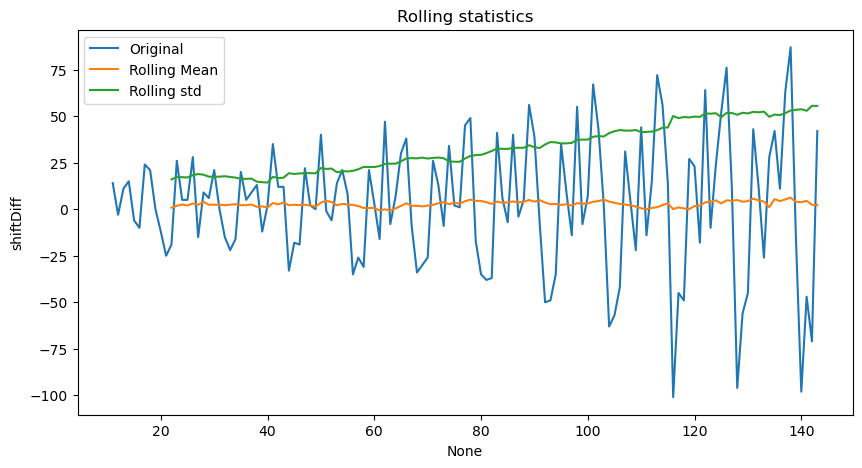

In [28]:
# data is not stationary - let us try 'diff' method
airp['shift']=airp.passengers.shift(1)
airp['shiftDiff']=airp['passengers']-airp['shift']
print(airp.head(20))
test_stationary(airp.dropna(),'shiftDiff')

    passengers    rollmean    rollstd  shift  shiftDiff
0          112         NaN        NaN    NaN        NaN
1          118         NaN        NaN    NaN        NaN
2          132         NaN        NaN  112.0       20.0
3          129         NaN        NaN  118.0       11.0
4          121         NaN        NaN  132.0      -11.0
5          135         NaN        NaN  129.0        6.0
6          148         NaN        NaN  121.0       27.0
7          148         NaN        NaN  135.0       13.0
8          136         NaN        NaN  148.0      -12.0
9          119         NaN        NaN  148.0      -29.0
10         104         NaN        NaN  136.0      -32.0
11         118  126.666667  13.720147  119.0       -1.0
12         115  126.916667  13.453342  104.0       11.0
13         126  127.583333  13.166475  118.0        8.0
14         141  128.333333  13.686977  115.0       26.0
15         135  128.833333  13.822467  126.0        9.0
16         125  129.166667  13.663710  141.0    

C:\Users\PGCP-AI\AppData\Local\Temp\ipykernel_11360\1974683370.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rollmean']=df[var].rolling(window=window).mean()
C:\Users\PGCP-AI\AppData\Local\Temp\ipykernel_11360\1974683370.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rollstd']=df[var].rolling(window=window).std()


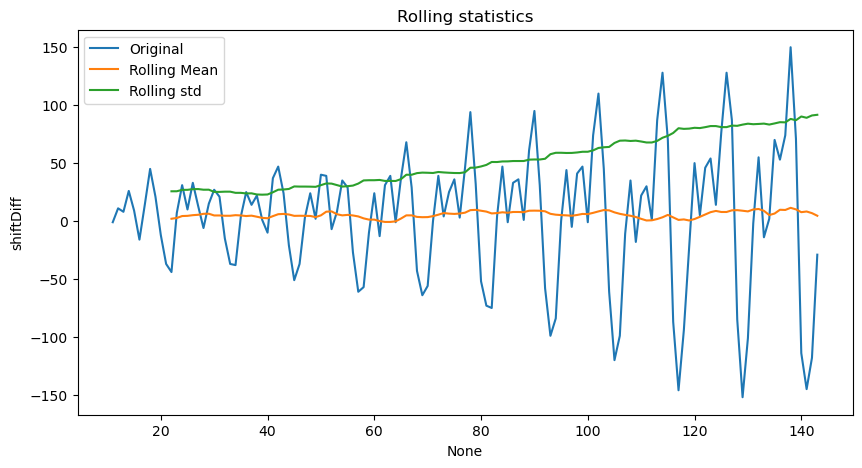

In [29]:
airp['shift']=airp.passengers.shift(2)
airp['shiftDiff']=airp['passengers']-airp['shift']
print(airp.head(20))
test_stationary(airp.dropna(),'shiftDiff')

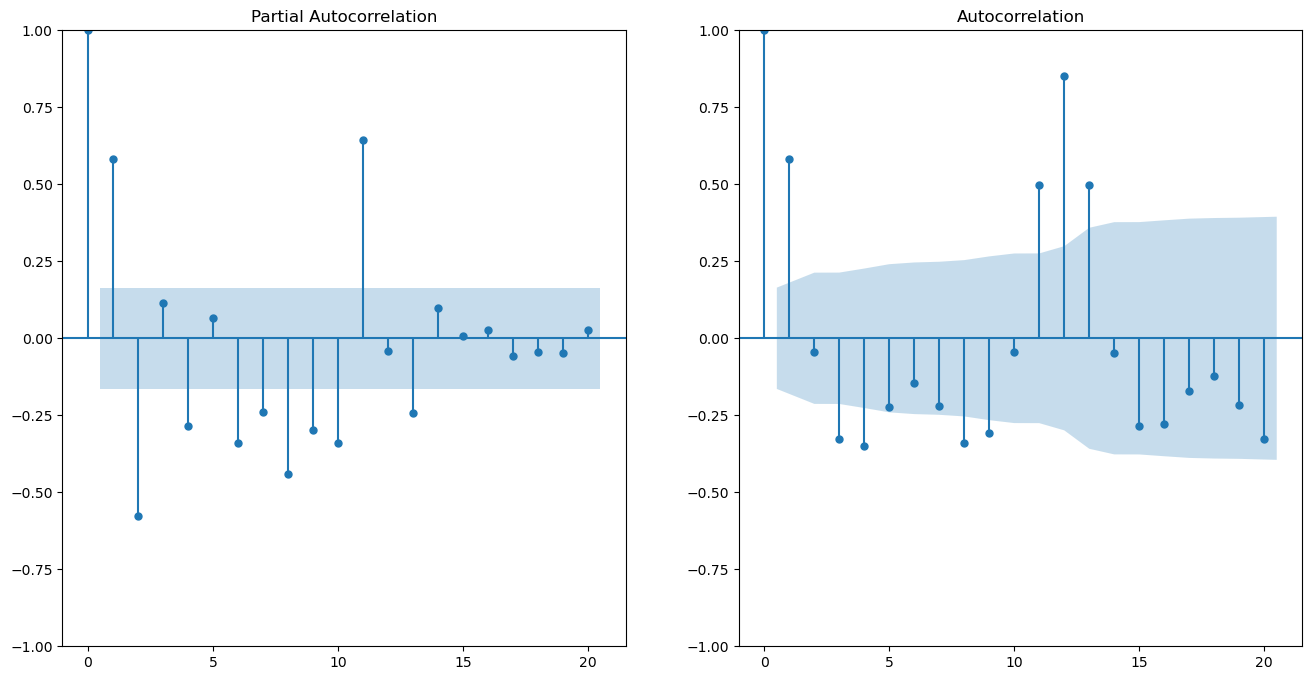

In [41]:
# ARIMA function: need 3 parameters:p,d,q
airp['secondDiff'] = airp['passengers'].diff(2)
airp['Diff12'] = airp['passengers'].diff(12)

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, (ax1,ax2) =plt.subplots(nrows=1,ncols=2,figsize=(16,8))
# PACF plot (gives p in ARIMA)
plot_pacf(airp['secondDiff'].dropna(),lags=20,ax=ax1)

# ACF plot(gives us 'q' in ARIMA)
plot_acf(airp['secondDiff'].dropna(),lags=20,ax=ax2)
plt.show()

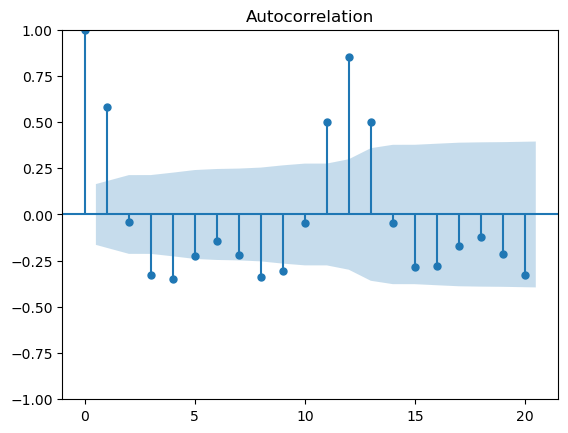

In [37]:
plot_acf(airp['secondDiff'].dropna(),lags=20)
plt.show()

In [43]:
# Train test split
train_size=int(len(airp)*0.7)
train=airp.iloc[:train_size]
test=airp.iloc[train_size:]

#ARIMA model
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
model_arima=ARIMA(train['passengers'],order=(1,2,1))
model_arima_fit=model_arima.fit()
arima_pred=model_arima_fit.predict(start=len(train),end=len(airp)-1)

#add arima pred to dataframe
airp['arimapred']=np.nan
airp.iloc[train_size:,airp.columns.get_loc('arimapred')]=arima_pred.values
print(airp.tail())
#ARIMA preds are bad


     passengers    rollmean    rollstd  shift  shiftDiff  secondDiff  Diff12  \
139         606  463.333333  83.630500  535.0       71.0        71.0    47.0   
140         508  467.083333  84.617276  622.0     -114.0      -114.0    45.0   
141         461  471.583333  82.541954  606.0     -145.0      -145.0    54.0   
142         390  473.916667  79.502382  508.0     -118.0      -118.0    28.0   
143         432  476.166667  77.737125  461.0      -29.0       -29.0    27.0   

      arimapred  
139  439.708767  
140  442.074513  
141  444.440259  
142  446.806004  
143  449.171750  


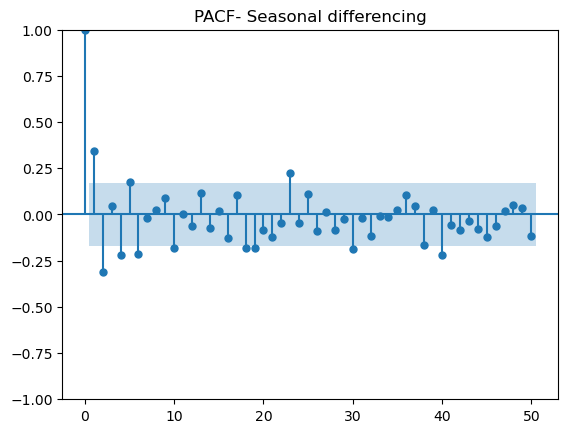

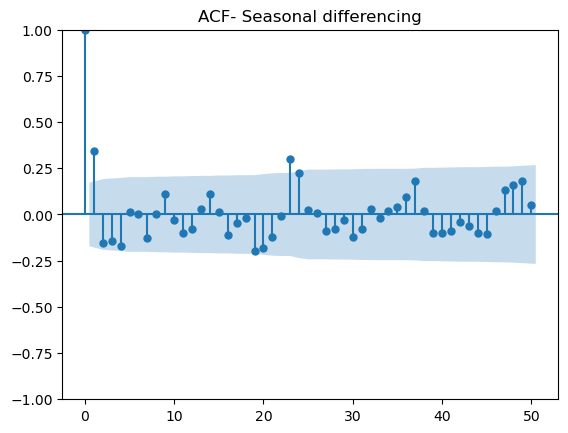

     passengers    rollmean    rollstd  shift  shiftDiff  secondDiff  Diff12  \
124         420  397.083333  60.008270  406.0       14.0        14.0    57.0   
125         472  400.166667  63.009138  396.0       76.0        76.0    37.0   
126         548  404.916667  71.987951  420.0      128.0       128.0    57.0   
127         559  409.416667  80.049369  472.0       87.0        87.0    54.0   
128         463  414.333333  81.485451  548.0      -85.0       -85.0    59.0   
129         407  418.333333  79.680422  559.0     -152.0      -152.0    48.0   
130         362  422.666667  74.498729  463.0     -101.0      -101.0    52.0   
131         405  428.333333  69.830097  407.0       -2.0        -2.0    68.0   
132         417  433.083333  66.624399  362.0       55.0        55.0    57.0   
133         391  437.166667  61.866180  405.0      -14.0       -14.0    49.0   
134         419  438.250000  61.382741  417.0        2.0         2.0    13.0   
135         461  443.666667  60.171472  

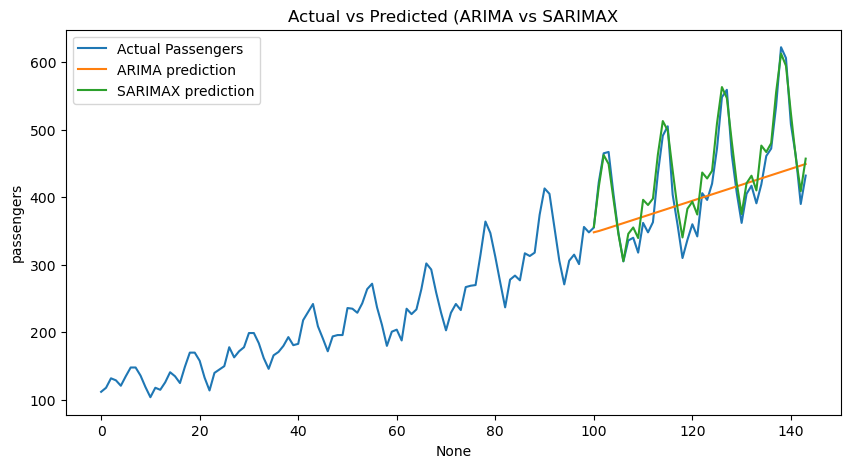

In [47]:
# SARIMAX prediction: seasonal component is used
# T calculate P and Q for SARIMAX 
airp['diff_combined'] = airp['passengers'].diff(2).diff(12)

plot_pacf(airp['diff_combined'].dropna(),lags=50)
plt.title('PACF- Seasonal differencing')
plt.show()

plot_acf(airp['diff_combined'].dropna(),lags=50)
plt.title('ACF- Seasonal differencing')
plt.show()

model_sarimax = SARIMAX(train['passengers'],order=(1,2,1),seasonal_order=(1,2,1,12))
model_sarimax_fit = model_sarimax.fit()
sarimax_pred = model_sarimax_fit.predict(start=len(train), end=len(airp)-1)

# Add SARIMAX prediction to dataframe
airp['sarimaxPred']=np.nan
airp.iloc[train_size:,airp.columns.get_loc('sarimaxPred')]=sarimax_pred.values
print(airp.tail(20))

# plot prediction
plt.figure(figsize=(10,5))
sns.lineplot(x=airp.index, y=airp['passengers'],label='Actual Passengers')
sns.lineplot(x=airp.index, y=airp['arimapred'],label='ARIMA prediction')
sns.lineplot(x=airp.index, y=airp['sarimaxPred'],label='SARIMAX prediction')

plt.title('Actual vs Predicted (ARIMA vs SARIMAX')
plt.legend()
plt.show()


In [48]:
# future forecast using sarimax

future_dates = pd.DataFrame(pd.date_range(start='1961-01-01',end='1962-12-01',freq='MS'),columns=['Dates'])
future_dates.set_index("Dates",inplace=True)

future_forecast = model_sarimax_fit.predict(start=future_dates.index[0],end=future_dates.index[-1])
print(future_forecast)

# Plot future forecast
plt.figure(figsize=(10,5))
sns.lineplot(x=airp.index, y=airp['passengers'],label='Actual Passengers')
sns.lineplot(x=airp.index, y=airp['sarimaxPred'],label='SARIMAX prediction')
future_forecast.plot(color='black',label='Future Forecast')
plt.title('SARIMAX model with future prediction')
plt.legend()
plt.show()

# model evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math
airp= airp.dropna()

# ARIMA metrics
arima_mae = mean_absolute_error(airp['passengers'],airp['arimapred'])
arima_mse = mean_squared_error(airp['passengers'],airp['arimapred'])
arima_rmse = math.sqrt(arima_mse)
arima_r2 = r2_score(airp['passengers'],airp['arimapred'])
print(f'ARIMA -> MAE:{arima_mae:.2f},RMSE:{arima_rmse:.2f},R^2:{arima_r2:.2f}')

# SARIMAX metrics
sarimax_mae = mean_absolute_error(airp['passengers'],airp['sarimaxpred'])
sarimax_mse = mean_squared_error(airp['passengers'],airp['sarimaxpred'])
sarimax_rmse = math.sqrt(arima_mse)
sarimax_r2 = r2_score(airp['passengers'],airp['sarimaxpred'])
print(f'ARIMA -> MAE:{sarimax_mae:.2f},RMSE:{sarimax_rmse:.2f},R^2:{sarimax_r2:.2f}')

KeyError: 'The `start` argument could not be matched to a location related to the index of the data.'